# Adult Census Income Classification

**Goal:** Predict whether a person's annual income exceeds \$50K based on census data (the classic UCI / Kaggle "Adult Census Income" dataset — [Kaggle: uciml/adult-census-income](https://www.kaggle.com/datasets/uciml/adult-census-income)).

**Note on data source:** Rather than manually downloading the file from Kaggle, this notebook pulls the dataset directly over HTTP at runtime from a public GitHub mirror of the same UCI Adult dataset that Kaggle's version is built from. This means the notebook is fully reproducible — just run all cells and the data is fetched automatically, no Kaggle account, API token, or manual upload required.

**Contents**
1. Load data (via URL)
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Preprocessing (encoding, scaling, train/test split)
5. Model training (Logistic Regression, Random Forest, Gradient Boosting)
6. Model evaluation & comparison
7. Feature importance
8. Conclusions


## 1. Load the dataset directly from a URL (no manual download)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Public mirror of the UCI Adult / Kaggle "Adult Census Income" dataset.
# Kaggle page: https://www.kaggle.com/datasets/uciml/adult-census-income
# (Kaggle downloads require an API token; this CSV is the same underlying
# UCI data served over plain HTTPS, so the notebook runs end-to-end with
# zero manual setup.)
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"

COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income'
]

df = pd.read_csv(
    DATA_URL,
    header=None,
    names=COLUMNS,
    na_values='?',
    skipinitialspace=True,
)

print("Shape:", df.shape)
df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education_num   48842 non-null  int64
 5   marital_status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital_gain    48842 non-null  int64
 11  capital_loss    48842 non-null  int64
 12  hours_per_week  48842 non-null  int64
 13  native_country  47985 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


## 2. Data Cleaning

`?` values in `workclass`, `occupation`, and `native_country` were already converted to `NaN` on load. We inspect and handle them below.

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:\n", missing)
print("\nRows with at least one missing value:", df.isna().any(axis=1).sum(),
      f"({df.isna().any(axis=1).mean()*100:.1f}% of data)")


Missing values per column:
 occupation        2809
workclass         2799
native_country     857
dtype: int64

Rows with at least one missing value: 3620 (7.4% of data)


In [4]:
# Drop exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

# For the categorical columns with missing values, impute with the mode
# (simplest, standard approach for this dataset; alternative would be to
# drop the ~7% of rows, but imputing keeps more data for training)
for col in ['workclass', 'occupation', 'native_country']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

assert df.isna().sum().sum() == 0
print("Missing values remaining:", df.isna().sum().sum())
print("Final shape:", df.shape)


Dropped 52 duplicate rows
Missing values remaining: 0
Final shape: (48790, 15)


In [5]:
# Clean target label (strip stray periods some source files include, normalize)
df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)
df['income'].value_counts()


income
<=50K    37109
>50K     11681
Name: count, dtype: int64

## 3. Exploratory Data Analysis

In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


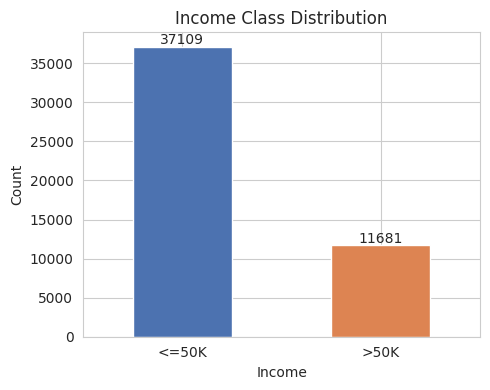

income
<=50K    76.058619
>50K     23.941381
Name: count, dtype: float64


In [7]:
target_counts = df['income'].value_counts()
ax = target_counts.plot(kind='bar', color=['#4C72B0', '#DD8452'], figsize=(5,4))
ax.set_title('Income Class Distribution')
ax.set_xlabel('Income')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts):
    ax.text(i, v + 300, str(v), ha='center')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(target_counts / target_counts.sum() * 100)


The classes are imbalanced (~76% earn `<=50K`, ~24% earn `>50K`), which we account for later by looking beyond accuracy (precision, recall, F1, ROC-AUC).

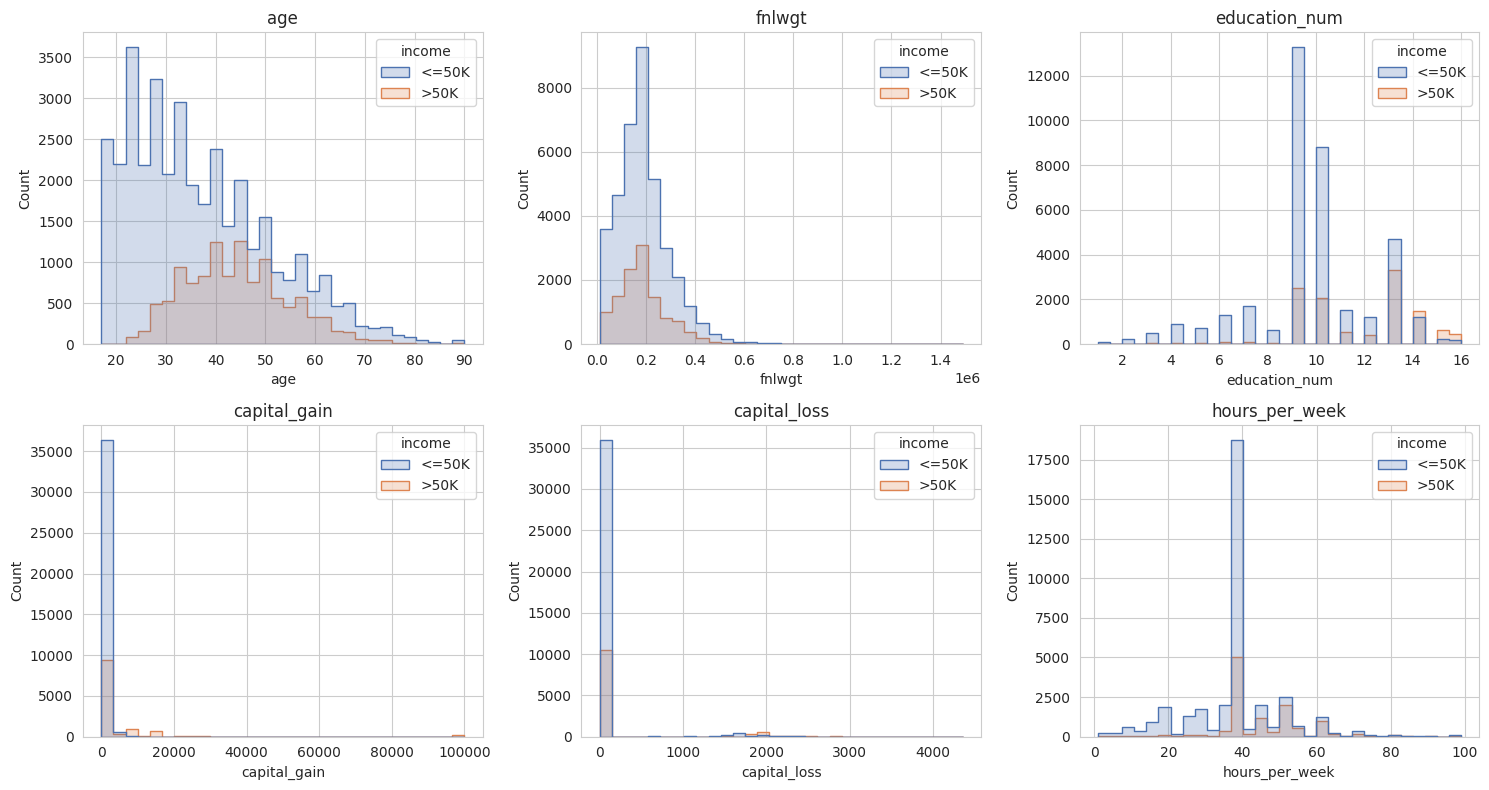

In [8]:
numeric_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=col, hue='income', bins=30, kde=False, ax=ax, palette=['#4C72B0','#DD8452'], element='step')
    ax.set_title(col)
plt.tight_layout()
plt.show()


/tmp/ipykernel_579/3693152151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y='age', ax=ax, palette=['#4C72B0','#DD8452'])


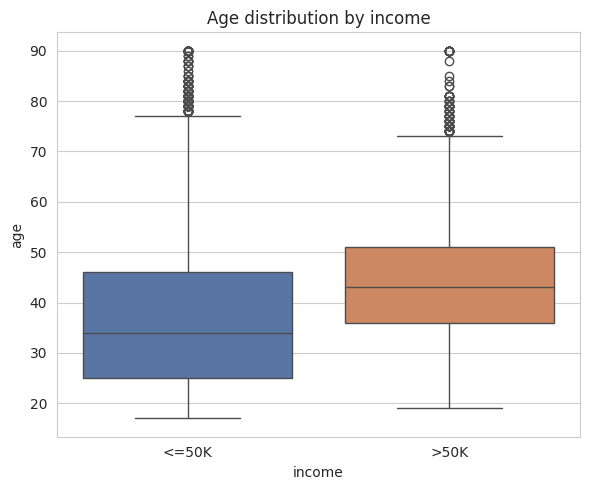

In [9]:
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=df, x='income', y='age', ax=ax, palette=['#4C72B0','#DD8452'])
ax.set_title('Age distribution by income')
plt.tight_layout()
plt.show()


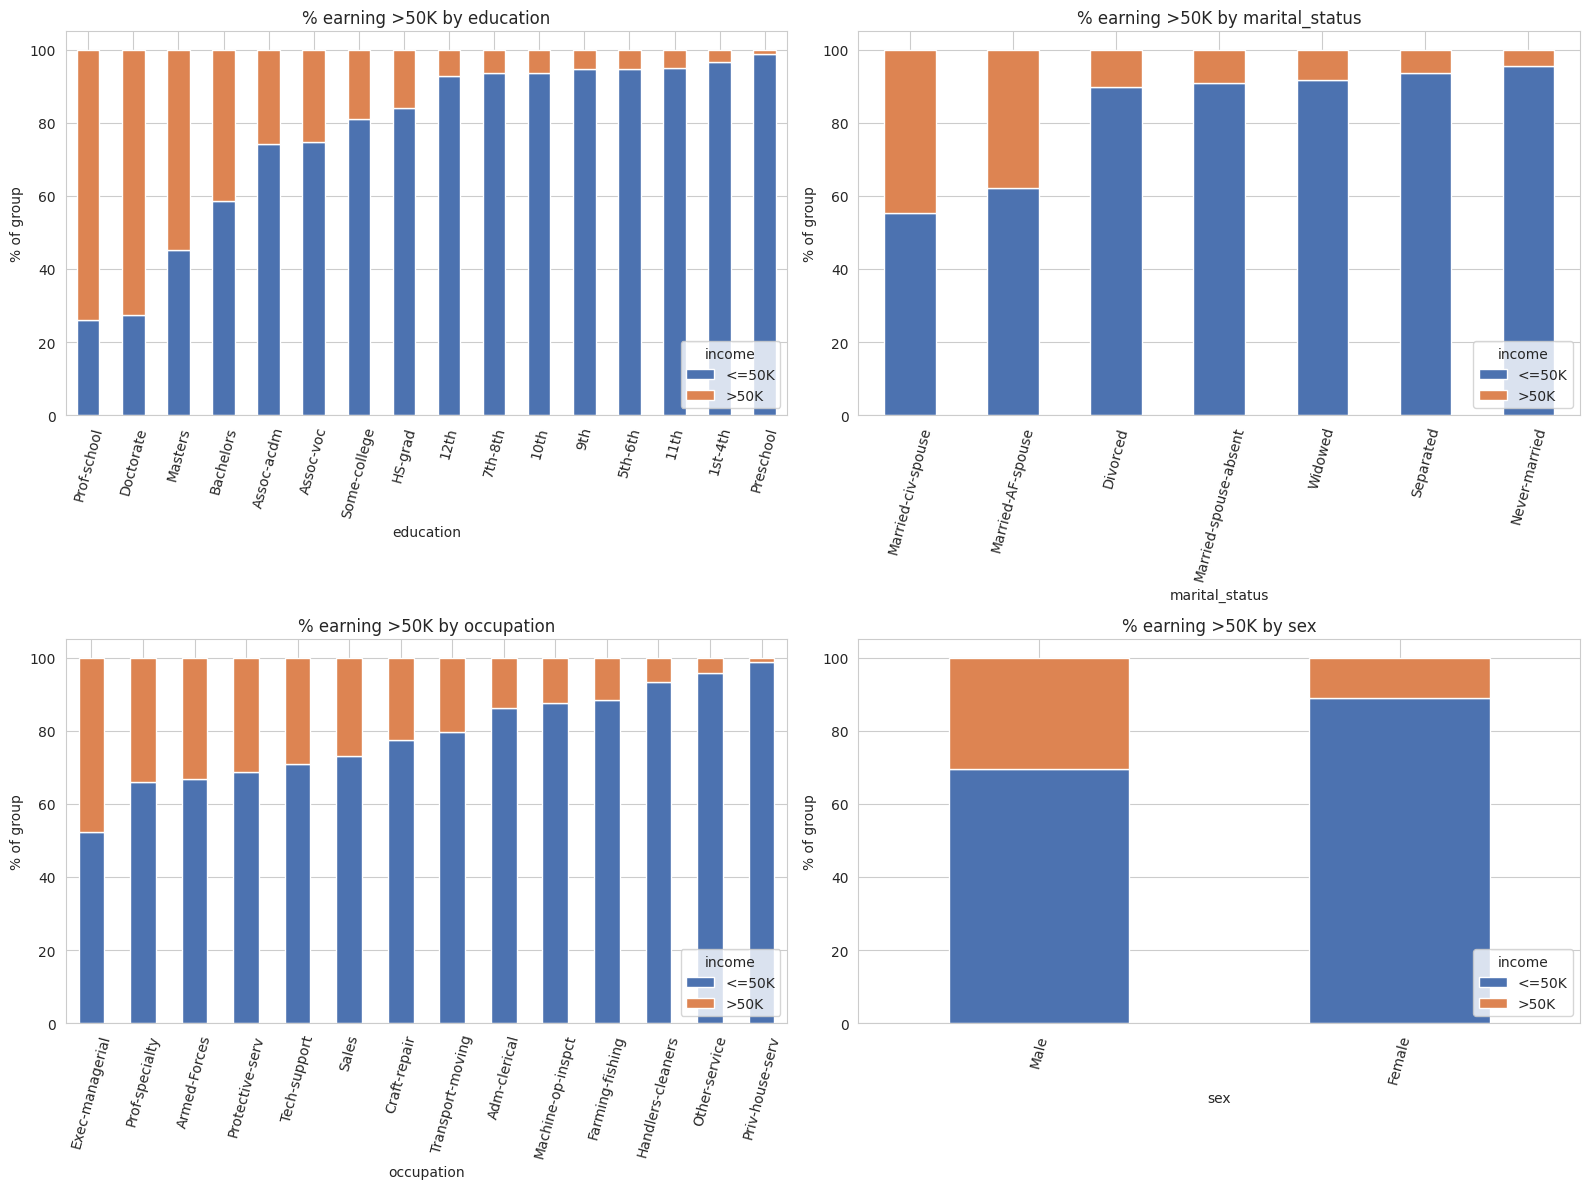

In [10]:
cat_cols_to_plot = ['education', 'marital_status', 'occupation', 'sex']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, col in zip(axes.flat, cat_cols_to_plot):
    ct = pd.crosstab(df[col], df['income'], normalize='index') * 100
    ct = ct.sort_values('>50K', ascending=False)
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
    ax.set_title(f'% earning >50K by {col}')
    ax.set_ylabel('% of group')
    ax.legend(title='income', loc='lower right')
    ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()


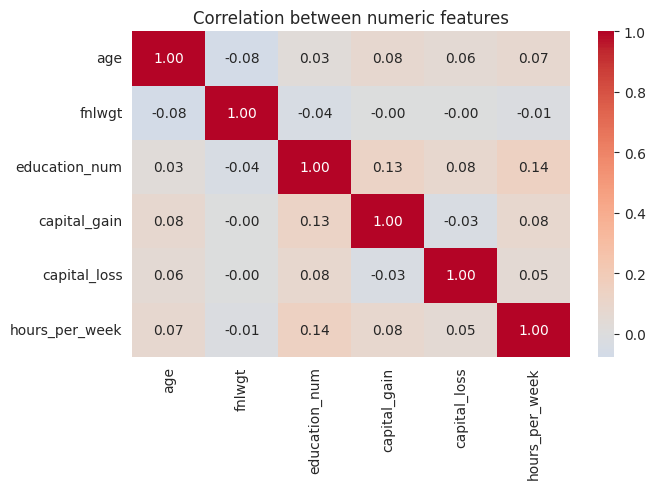

In [11]:
plt.figure(figsize=(7,5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation between numeric features')
plt.tight_layout()
plt.show()


**EDA takeaways**
- Income is strongly associated with `education_num`, `marital_status` (married individuals earn more), `hours_per_week`, `age` (up to a point), and having non-zero `capital_gain`.
- `fnlwgt` is a census sampling weight, not a real predictive feature about the individual — it will be dropped before modeling.
- Class imbalance (~76/24) means accuracy alone is not the most reliable metric.

## 4. Preprocessing

- Drop `fnlwgt` (not informative about the individual) and `education` (redundant with `education_num`).
- One-hot encode remaining categorical features.
- Encode the target (`<=50K` -> 0, `>50K` -> 1).
- Split into train/test sets (80/20, stratified).
- Scale numeric features for the linear model.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

model_df = df.drop(columns=['fnlwgt', 'education']).copy()

y = (model_df['income'] == '>50K').astype(int)
X = model_df.drop(columns=['income'])

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols_model = X.select_dtypes(exclude='object').columns.tolist()
print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols_model)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("\nEncoded feature matrix shape:", X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols_model] = scaler.fit_transform(X_train[numeric_cols_model])
X_test_scaled[numeric_cols_model] = scaler.transform(X_test[numeric_cols_model])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))


Categorical: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Numeric: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Encoded feature matrix shape: (48790, 81)
Train shape: (39032, 81)  Test shape: (9758, 81)
Train class balance:
 income
0    0.760581
1    0.239419
Name: proportion, dtype: float64


/tmp/ipykernel_579/2096501518.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


## 5. Model Training

We train and compare three classifiers:
1. **Logistic Regression** (baseline linear model, uses scaled features)
2. **Random Forest** (bagged trees, robust to feature scale/type)
3. **Gradient Boosting** (boosted trees, typically strong on tabular data)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import time

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, n_jobs=-1, random_state=42), False),
    'Gradient Boosting': (GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42), False),
}

results = {}
fitted_models = {}

for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    Xte = X_test_scaled if needs_scaling else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Train time (s)': train_time,
    }
    fitted_models[name] = (model, y_pred, y_proba)
    print(f"Trained {name} in {train_time:.2f}s")


Trained Logistic Regression in 0.66s


Trained Random Forest in 8.26s


Trained Gradient Boosting in 8.68s


## 6. Model Evaluation & Comparison

In [14]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC,Train time (s)
Gradient Boosting,0.8754,0.7911,0.6515,0.7146,0.9297,8.6844
Random Forest,0.8695,0.7829,0.6297,0.6980,0.9226,8.2650
Logistic Regression,0.8531,0.7309,0.6117,0.6660,0.9076,0.6557


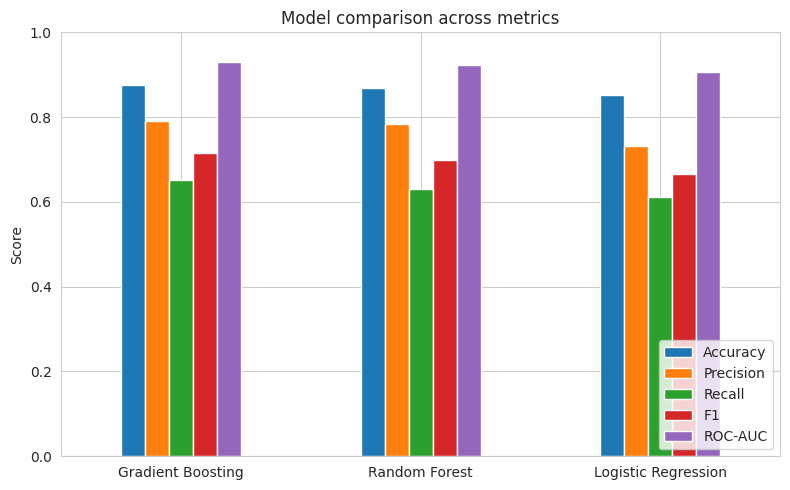

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
results_df[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(kind='bar', ax=ax)
ax.set_title('Model comparison across metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


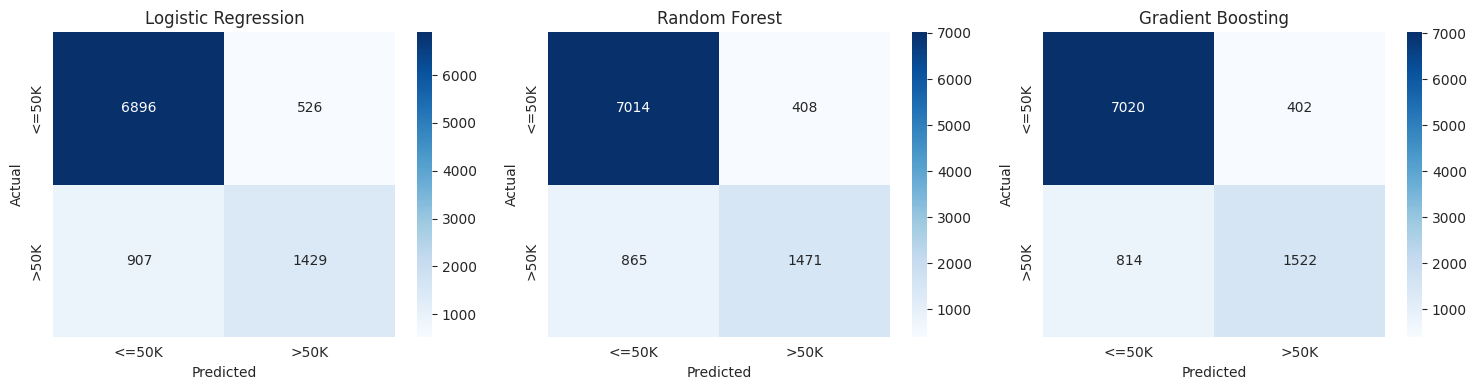

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (model, y_pred, y_proba)) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


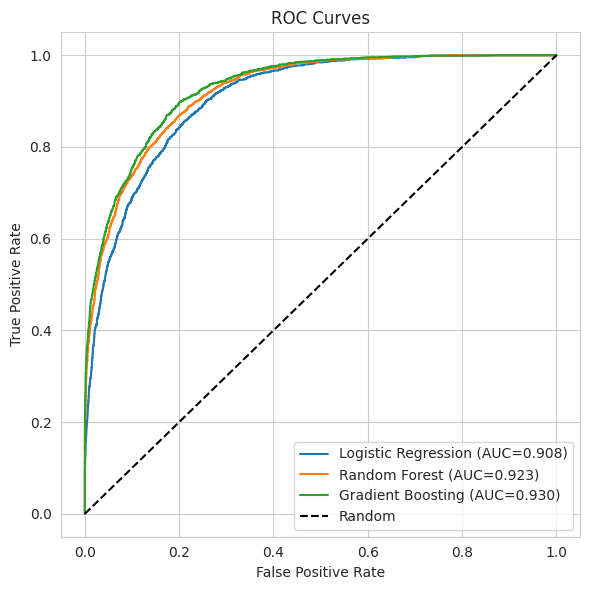

In [17]:
plt.figure(figsize=(6,6))
for name, (model, y_pred, y_proba) in fitted_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
best_name = results_df.index[0]
best_model, best_pred, best_proba = fitted_models[best_name]
print(f"Best model by ROC-AUC: {best_name}\n")
print(classification_report(y_test, best_pred, target_names=['<=50K', '>50K']))


Best model by ROC-AUC: Gradient Boosting

              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      7422
        >50K       0.79      0.65      0.71      2336

    accuracy                           0.88      9758
   macro avg       0.84      0.80      0.82      9758
weighted avg       0.87      0.88      0.87      9758



## 7. Feature Importance (best tree-based model)

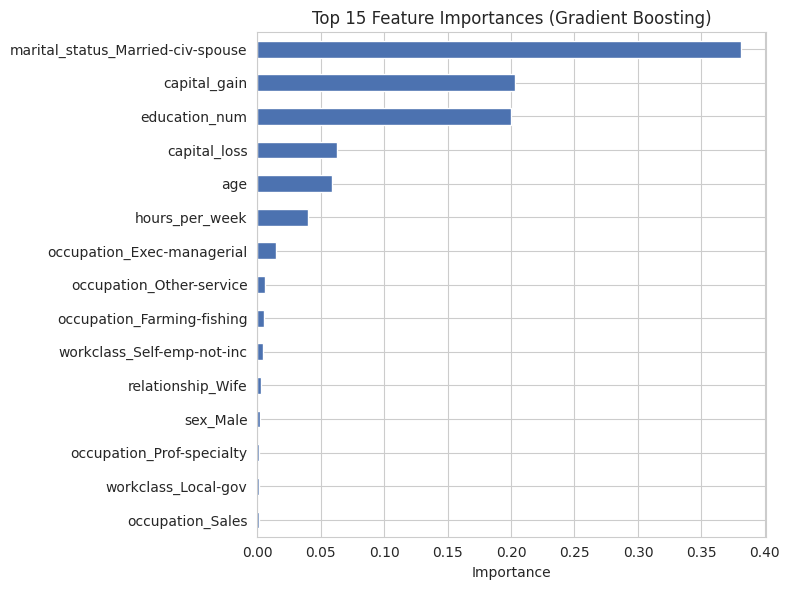

In [19]:
tree_models = {k: v for k, v in fitted_models.items() if k in ('Random Forest', 'Gradient Boosting')}
importance_source = best_name if best_name in tree_models else 'Random Forest'
imp_model = fitted_models[importance_source][0]

importances = pd.Series(imp_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh', color='#4C72B0')
plt.title(f'Top 15 Feature Importances ({importance_source})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 8. Conclusions

- After cleaning (removing duplicates, imputing missing categorical values) and encoding, three classifiers were trained on the Adult Census Income data: Logistic Regression, Random Forest, and Gradient Boosting.
- The results table and ROC curves above show how the models compare on accuracy, precision, recall, F1, and ROC-AUC — the metrics beyond accuracy matter here since the target is imbalanced (~76% `<=50K` / ~24% `>50K`).
- The most consistently important predictors of income (from the feature importance chart) tend to be marital/relationship status, education level, capital gain, age, and hours worked per week — consistent with the EDA in Section 3.
- Possible next steps: hyperparameter tuning (e.g. `GridSearchCV`/`RandomizedSearchCV`), trying gradient boosting libraries such as XGBoost/LightGBM, handling class imbalance explicitly (class weights or SMOTE), and probability calibration.
